<a href="https://colab.research.google.com/github/Rohit820911/MobileNet-CIFAR10-Image-Classification/blob/main/MobileNet_CIFAR10_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
from tensorflow.keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print(x_train.shape)
print(y_train.shape)

(50000, 32, 32, 3)
(50000, 1)


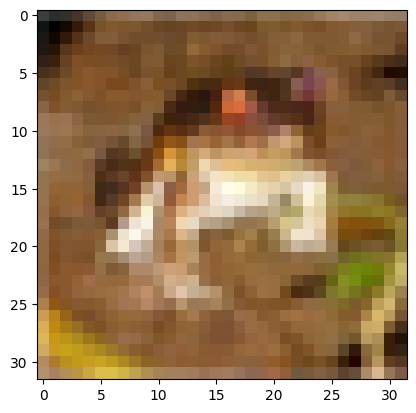

In [25]:
import matplotlib.pyplot as plt

plt.imshow(x_train[0])
plt.show()

In [32]:
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

def preprocess(image, label):
    image = tf.image.resize(image, (96, 96))
    image = preprocess_input(tf.cast(image, tf.float32))
    return image, label

train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_ds = train_ds.shuffle(10000).map(preprocess, num_parallel_calls=tf.data.AUTOTUNE).batch(32).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_ds = test_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE).batch(32).prefetch(tf.data.AUTOTUNE)

In [27]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(
    input_shape=(96, 96, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

In [28]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [33]:
history = model.fit(
    train_ds,
    epochs=10,
    validation_data=test_ds
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 32s 15ms/step - accuracy: 0.6037 - loss: 1.2056 - val_accuracy: 0.8020 - val_loss: 0.5849
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.7842 - loss: 0.6381 - val_accuracy: 0.8289 - val_loss: 0.4945
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.8136 - loss: 0.5535 - val_accuracy: 0.8427 - val_loss: 0.4578
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.8257 - loss: 0.5082 - val_accuracy: 0.8472 - val_loss: 0.4397
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.8346 - loss: 0.4812 - val_accuracy: 0.8506 - val_loss: 0.4263
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.8422 - loss: 0.4662 - val_accuracy: 0.8524 - val_loss: 0.4171
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.8442 - loss: 0.4489 - val_accuracy: 0.8545 - val_loss: 0.4106
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.8495 -

In [34]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8605 - loss: 0.3979
Test accuracy: 0.8604999780654907


In [35]:
model.save("mobilenet_cifar10.keras")

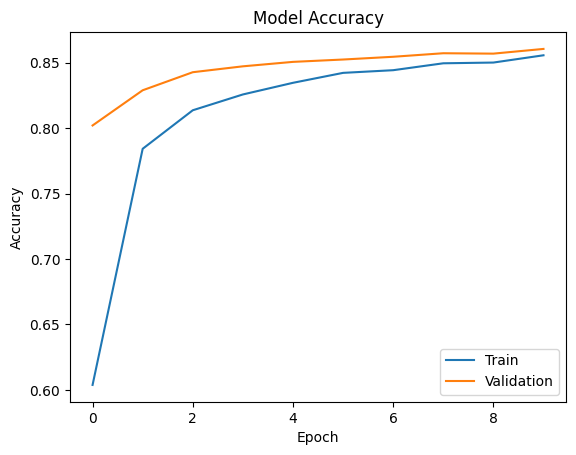

In [36]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

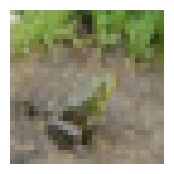

Actual: frog
Predicted: frog


In [41]:
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# random image index
index = random.randint(0, len(x_test)-1)

# original image
img = x_test[index]

# actual label
actual_class = y_test[index][0]

# show image
plt.figure(figsize=(2,2))
plt.imshow(img)
plt.axis('off')
plt.show()

# preprocess image for MobileNet
img_resized = tf.image.resize(img, (96, 96))
img_resized = preprocess_input(tf.cast(img_resized, tf.float32))
img_resized = tf.expand_dims(img_resized, axis=0)

# prediction
prediction = model.predict(img_resized, verbose=0)
predicted_class = np.argmax(prediction[0])

print("Actual:", class_names[actual_class])
print("Predicted:", class_names[predicted_class])